## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [550]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [551]:
import warnings
warnings.filterwarnings('ignore')

In [552]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [553]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [554]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [555]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.64007,39.68498,2023-08-01,2023,8,2023-08-01,39.685323,22.639791,0.184913,-0.165574,-0.260881,0.165574,0.246690,-0.103494,-0.309804,0.103494,0.045078,0.043212,0.041277,0.043212,2023-08-01,39.685323,22.639791,15639.0,14845.0,39.685323,22.639791,14234.555556,13815.416667,14262.375000,13795.705882,14727.384615,14018.071429,14844.400000,14065.666667,2023-08-01,39.650181,22.650104,172.699636,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
1,αγιας,θεσσαλιας,22.84384,39.71642,2023-08-01,2023,8,2023-08-01,39.716764,22.841912,0.644562,0.299488,-0.527094,-0.299488,0.601767,0.263909,-0.507761,-0.263909,0.053740,0.067434,0.027879,0.067434,2023-08-01,39.716764,22.841912,15158.0,14782.0,39.716764,22.841912,14184.833333,13986.400000,14202.187500,13905.400000,14410.125000,14070.384615,14473.153846,14180.166667,2023-08-01,39.750182,22.850105,195.825748,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
2,αγιας,θεσσαλιας,22.84384,39.68498,2023-08-01,2023,8,2023-08-01,39.685323,22.841912,0.682190,0.328859,-0.533123,-0.328859,0.621858,0.270561,-0.512111,-0.270561,0.051602,0.058987,0.022746,0.058987,2023-08-01,39.685323,22.841912,15149.0,14747.0,39.685323,22.841912,14208.692308,13932.357143,14221.066667,13943.933333,14436.857143,14075.307692,14543.666667,14163.714286,2023-08-01,39.650181,22.850105,190.688926,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
3,αγιας,θεσσαλιας,22.84384,39.65354,2023-08-01,2023,8,2023-08-01,39.653882,22.841912,0.763326,0.362633,-0.625676,-0.362633,0.752499,0.370866,-0.611549,-0.370866,0.008775,0.011080,0.012484,0.011080,2023-08-01,39.653882,22.841912,15073.0,14754.0,39.653882,22.841912,14163.600000,13951.500000,14164.705882,13921.307692,14443.076923,14025.300000,14483.461538,14151.333333,2023-08-01,39.650181,22.850105,190.688926,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
4,αγιας,θεσσαλιας,22.84384,39.62210,2023-08-01,2023,8,2023-08-01,39.622441,22.841912,0.716087,0.294069,-0.585718,-0.294069,0.735496,0.319319,-0.604444,-0.319319,0.029232,0.035759,0.024882,0.035759,2023-08-01,39.622441,22.841912,14837.0,14667.0,39.622441,22.841912,14163.214286,13874.285714,14139.062500,13843.583333,14463.000000,13991.357143,14435.500000,14070.857143,2023-08-01,39.650181,22.850105,190.688926,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0


In [556]:
#wnv_file.head()

In [557]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [558]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [559]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.64007,39.68498,2023-08-01,2023,8,0.184913,-0.165574,-0.260881,0.165574,0.246690,-0.103494,-0.309804,0.103494,0.045078,0.043212,0.041277,0.043212,15639.0,14845.0,14234.555556,13815.416667,14262.375000,13795.705882,14727.384615,14018.071429,14844.400000,14065.666667,172.699636,0.0,0.0
1,αγιας,θεσσαλιας,22.84384,39.71642,2023-08-01,2023,8,0.644562,0.299488,-0.527094,-0.299488,0.601767,0.263909,-0.507761,-0.263909,0.053740,0.067434,0.027879,0.067434,15158.0,14782.0,14184.833333,13986.400000,14202.187500,13905.400000,14410.125000,14070.384615,14473.153846,14180.166667,195.825748,0.0,0.0
2,αγιας,θεσσαλιας,22.84384,39.68498,2023-08-01,2023,8,0.682190,0.328859,-0.533123,-0.328859,0.621858,0.270561,-0.512111,-0.270561,0.051602,0.058987,0.022746,0.058987,15149.0,14747.0,14208.692308,13932.357143,14221.066667,13943.933333,14436.857143,14075.307692,14543.666667,14163.714286,190.688926,0.0,0.0
3,αγιας,θεσσαλιας,22.84384,39.65354,2023-08-01,2023,8,0.763326,0.362633,-0.625676,-0.362633,0.752499,0.370866,-0.611549,-0.370866,0.008775,0.011080,0.012484,0.011080,15073.0,14754.0,14163.600000,13951.500000,14164.705882,13921.307692,14443.076923,14025.300000,14483.461538,14151.333333,190.688926,0.0,0.0
4,αγιας,θεσσαλιας,22.84384,39.62210,2023-08-01,2023,8,0.716087,0.294069,-0.585718,-0.294069,0.735496,0.319319,-0.604444,-0.319319,0.029232,0.035759,0.024882,0.035759,14837.0,14667.0,14163.214286,13874.285714,14139.062500,13843.583333,14463.000000,13991.357143,14435.500000,14070.857143,190.688926,0.0,0.0


In [560]:
#wnv_file.head(5)

### Merge Timeline and WNV Case Files ###

In [561]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [562]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [563]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [564]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [565]:
# merged

In [566]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [567]:
merged['case'].value_counts()

0    639
Name: case, dtype: int64

In [568]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-08-01,αγιας,θεσσαλιας,22.761054,39.691860,2023.0,8.0,0.557438,0.178412,-0.487907,-0.178412,0.520525,0.179898,-0.454158,-0.179898,0.051547,0.045856,0.036236,0.045856,15189.062500,14726.656250,14178.409279,13860.346144,14171.760540,13828.691926,14491.034006,13968.883041,14550.373822,14053.339757,184.584776,0.000000,0.000000,0.0
1,2023-08-01,αλμυρου,θεσσαλιας,22.726710,39.125600,2023.0,8.0,0.420595,0.107140,-0.386961,-0.107140,0.395690,0.099732,-0.366670,-0.099732,0.072532,0.065109,0.051319,0.065109,15380.541667,14756.125000,14218.465488,13849.790198,14194.064068,13807.818694,14492.576679,13976.379195,14613.298276,14062.227042,278.949415,0.000111,0.000111,0.0
2,2023-08-01,αλοννησου,θεσσαλιας,23.998420,39.245850,2023.0,8.0,-0.253788,0.387324,0.474667,-0.387324,-0.232008,0.321657,0.441268,-0.321657,0.015256,0.046027,0.024071,0.046027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.685311,0.000000,0.000000,0.0
3,2023-08-01,αργιθεας,θεσσαλιας,21.485102,39.296296,2023.0,8.0,0.555144,0.196079,-0.487694,-0.196079,0.557115,0.191109,-0.488342,-0.191109,0.077085,0.064546,0.052469,0.064546,14999.923077,14612.153846,14004.639277,13749.094863,14010.616238,13627.205397,14313.543797,13842.260526,14353.779532,13871.753294,229.373225,0.000000,0.000000,0.0
4,2023-08-01,βολου,θεσσαλιας,22.935020,39.381170,2023.0,8.0,0.390260,0.033993,-0.363181,-0.033993,0.334020,0.026989,-0.317529,-0.026989,0.057719,0.059415,0.050660,0.059415,15403.333333,14774.416667,14265.470978,13867.442537,14227.234959,13849.771871,14519.570944,13957.247128,14652.483047,14063.726521,208.427446,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-08-01,τεμπων,θεσσαλιας,22.542882,39.850899,2023.0,8.0,0.413375,0.085477,-0.382376,-0.085477,0.389791,0.067347,-0.366998,-0.067347,0.054164,0.050260,0.041220,0.050260,15322.307692,14758.461538,14177.178067,13807.944324,14177.032020,13764.242791,14508.786409,13955.557140,14599.021795,14043.976923,151.094659,0.000000,0.000000,0.0
21,2023-08-01,τρικκαιων,θεσσαλιας,21.774345,39.612926,2023.0,8.0,0.438171,0.055794,-0.434343,-0.055794,0.450294,0.074011,-0.440591,-0.074011,0.067055,0.061030,0.042668,0.061030,15398.181818,14827.909091,14203.631413,13794.260331,14367.123987,13763.545005,14634.507757,13990.443939,14744.208789,14058.258766,327.791186,0.000000,0.000000,0.0
22,2023-08-01,τυρναβου,θεσσαλιας,22.296112,39.762971,2023.0,8.0,0.297228,-0.051208,-0.340381,0.051208,0.315149,-0.031116,-0.346138,0.031116,0.060882,0.054054,0.039207,0.054054,15572.291667,14840.375000,14223.076098,13786.371190,14306.576428,13754.586973,14633.179247,13980.393057,14774.108768,14084.721892,135.011355,0.000000,0.000000,0.0
23,2023-08-01,φαρκαδονας,θεσσαλιας,22.026290,39.603000,2023.0,8.0,0.372659,-0.019761,-0.403419,0.019761,0.365735,-0.028541,-0.395658,0.028541,0.067264,0.069817,0.040086,0.069817,15513.090909,14892.909091,14210.322756,13821.391275,14343.387140,13806.079211,14667.374263,14017.148065,14739.328945,14081.559848,221.413648,0.000000,0.000000,0.0


In [569]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset = dataset.astype({'case': 'int'})
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)
lau1_map = lau1_mapping(dataset, 0, 0)

In [570]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

### Add mosqutio predictions using trained model ###

In [571]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [572]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [573]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [574]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [575]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [576]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [577]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [578]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

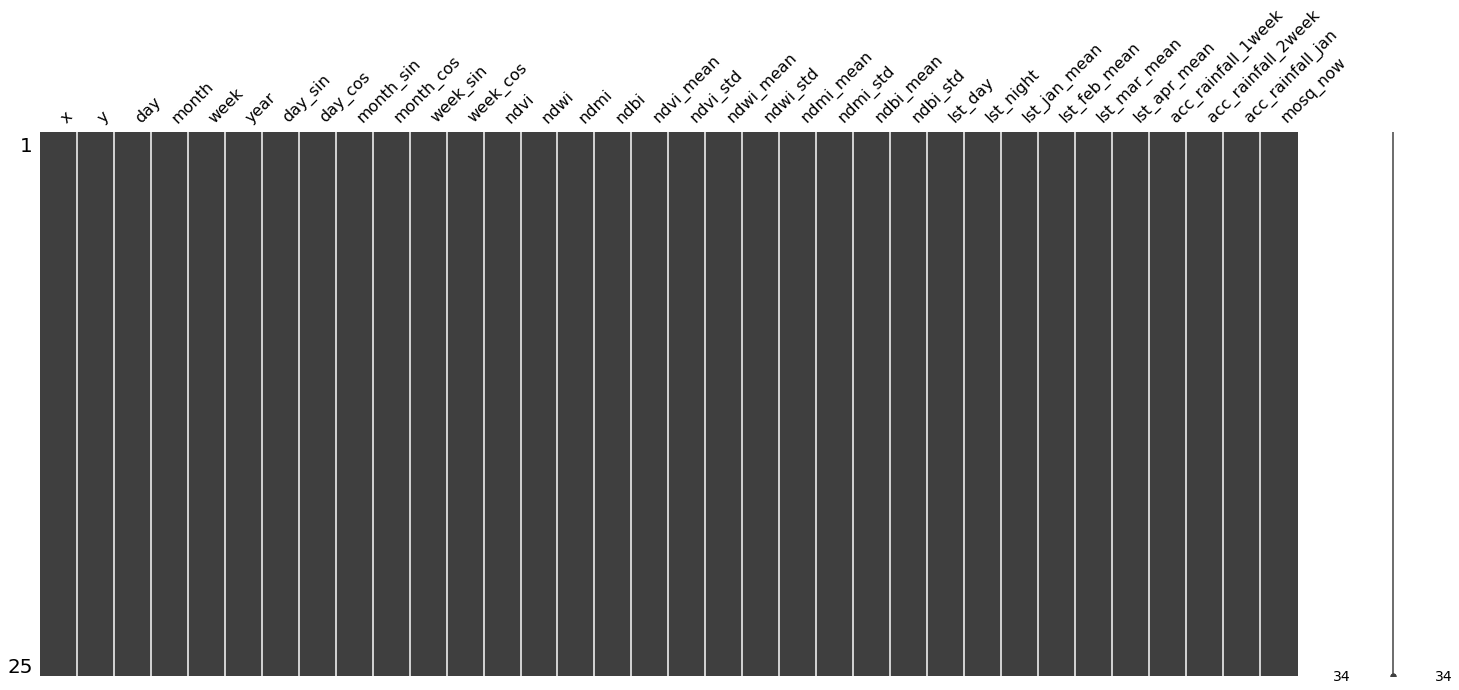

In [579]:
missingno.matrix(dataset_mamoth)

In [580]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [581]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [582]:
predictions = give_predictions(model, dataset_mamoth)

In [583]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.76105,39.69186,2023-08-01,33
1,22.72671,39.12560,2023-08-01,35
2,23.99842,39.24585,2023-08-01,1
3,21.48510,39.29630,2023-08-01,41
4,22.93502,39.38117,2023-08-01,50
...,...,...,...,...
20,22.54288,39.85090,2023-08-01,84
21,21.77435,39.61293,2023-08-01,90
22,22.29611,39.76297,2023-08-01,111
23,22.02629,39.60300,2023-08-01,119


In [584]:
#This cell writes the mosquito predictions to a seperate .csv file

# mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [585]:
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

mosqutio_predictions['x.approx'] = mosqutio_predictions['x'].apply(lambda x : round(x,5))
mosqutio_predictions['y.approx'] = mosqutio_predictions['y'].apply(lambda x : round(x,5))

In [586]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

In [587]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)

In [588]:
dataset.distance.max()

0.0

In [589]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [590]:
dataset.reset_index(inplace=True, drop=True)

<AxesSubplot:>

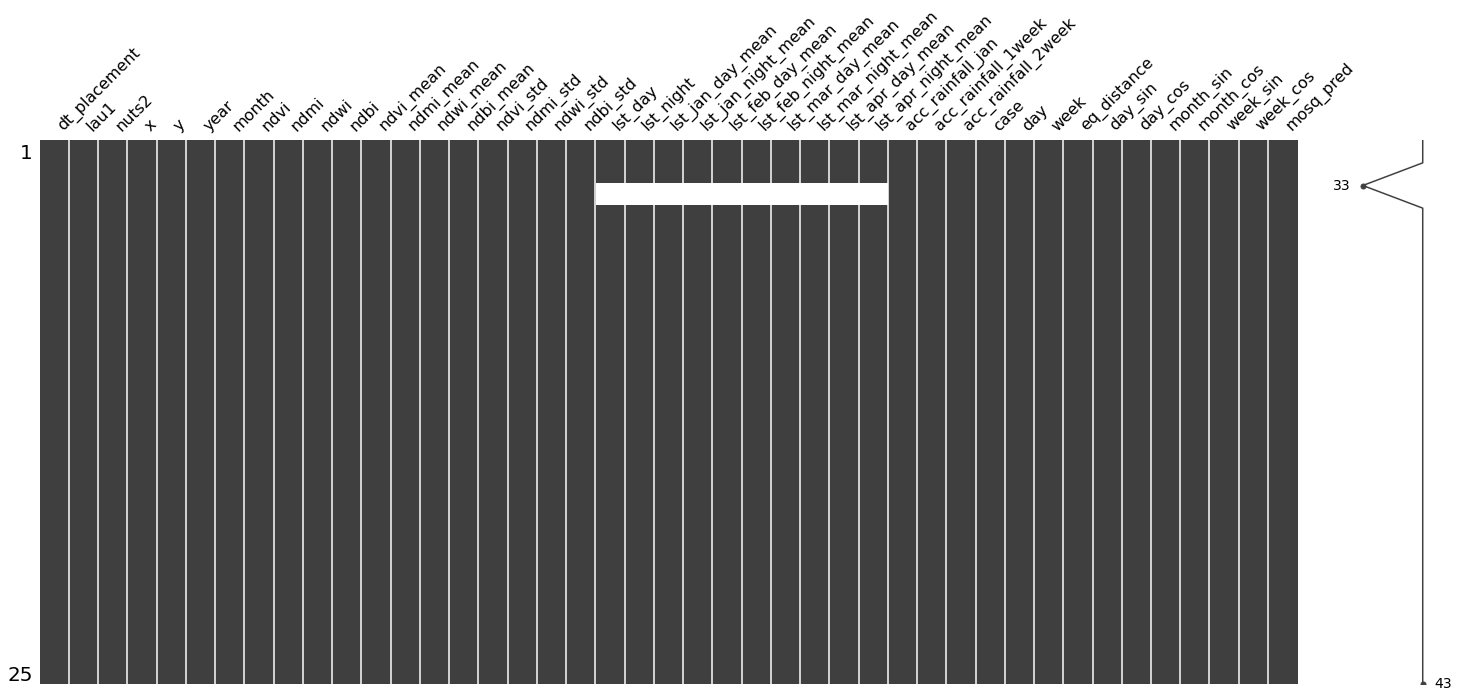

In [591]:
missingno.matrix(dataset)

### Add Demographic features ###

In [592]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [593]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [594]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [595]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [596]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [597]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['καλαμπακας', 'λαρισαιων', 'ρηγα φερραιου', 'φαρκαδονας']

Length: 4


In [598]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ρηγα φεραιου','ρηγα φερραιου'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))


In [599]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [600]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

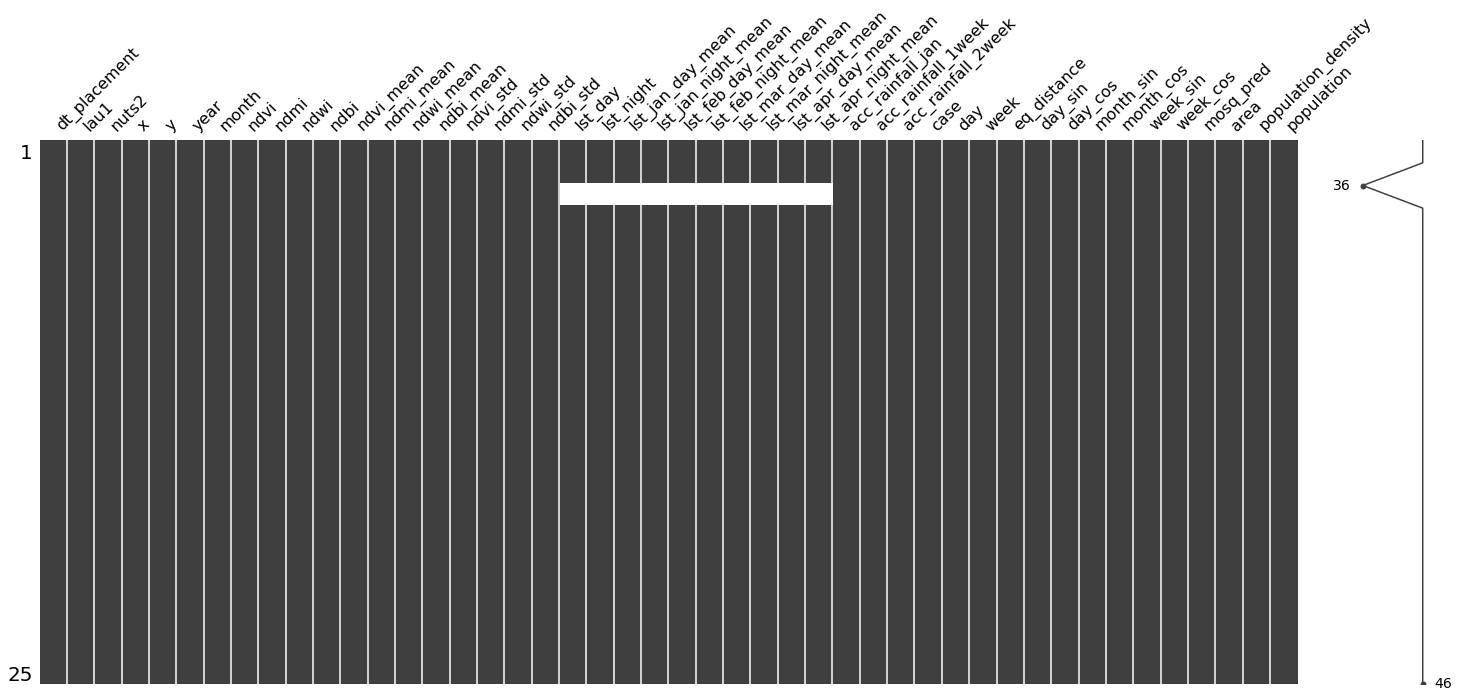

In [601]:
missingno.matrix(dataset)

In [602]:
missing = describe_dataframe(dataset)

In [603]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,area,population_density,population
0,2023-08-01,αγιας,θεσσαλιας,22.76105,39.69186,2023,8,0.557438,0.178412,-0.487907,-0.178412,0.520525,0.179898,-0.454158,-0.179898,0.051547,0.045856,0.036236,0.045856,15189.062500,14726.656250,14178.409279,13860.346144,14171.760540,13828.691926,14491.034006,13968.883041,14550.373822,14053.339757,184.584776,0.000000,0.000000,0,1,31,45.75488,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,33,661.8,17.3,10705.00
1,2023-08-01,αλμυρου,θεσσαλιας,22.72671,39.12560,2023,8,0.420595,0.107140,-0.386961,-0.107140,0.395690,0.099732,-0.366670,-0.099732,0.072532,0.065109,0.051319,0.065109,15380.541667,14756.125000,14218.465488,13849.790198,14194.064068,13807.818694,14492.576679,13976.379195,14613.298276,14062.227042,278.949415,0.000111,0.000111,0,1,31,45.24728,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,35,905.4,20.6,16004.00
2,2023-08-01,αλοννησου,θεσσαλιας,23.99842,39.24585,2023,8,-0.253788,0.387324,0.474667,-0.387324,-0.232008,0.321657,0.441268,-0.321657,0.015256,0.046027,0.024071,0.046027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.685311,0.000000,0.000000,0,1,31,46.00175,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,1,129.6,21.2,3153.00
3,2023-08-01,αργιθεας,θεσσαλιας,21.48510,39.29630,2023,8,0.555144,0.196079,-0.487694,-0.196079,0.557115,0.191109,-0.488342,-0.191109,0.077085,0.064546,0.052469,0.064546,14999.923077,14612.153846,14004.639277,13749.094863,14010.616238,13627.205397,14313.543797,13842.260526,14353.779532,13871.753294,229.373225,0.000000,0.000000,0,1,31,44.78626,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,41,372.9,9.3,3515.00
4,2023-08-01,βολου,θεσσαλιας,22.93502,39.38117,2023,8,0.390260,0.033993,-0.363181,-0.033993,0.334020,0.026989,-0.317529,-0.026989,0.057719,0.059415,0.050660,0.059415,15403.333333,14774.416667,14265.470978,13867.442537,14227.234959,13849.771871,14519.570944,13957.247128,14652.483047,14063.726521,208.427446,0.000000,0.000000,0,1,31,45.57293,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,50,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-08-01,τεμπων,θεσσαλιας,22.54288,39.85090,2023,8,0.413375,0.085477,-0.382376,-0.085477,0.389791,0.067347,-0.366998,-0.067347,0.054164,0.050260,0.041220,0.050260,15322.307692,14758.461538,14177.178067,13807.944324,14177.032020,13764.242791,14508.786409,13955.557140,14599.021795,14043.976923,151.094659,0.000000,0.000000,0,1,31,45.78510,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,84,576.7,23.8,11.99
21,2023-08-01,τρικκαιων,θεσσαλιας,21.77435,39.61293,2023,8,0.438171,0.055794,-0.434343,-0.055794,0.450294,0.074011,-0.440591,-0.074011,0.067055,0.061030,0.042668,0.061030,15398.181818,14827.909091,14203.631413,13794.260331,14367.123987,13763.545005,14634.507757,13990.443939,14744.208789,14058.258766,327.791186,0.000000,0.000000,0,1,31,45.20295,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,90,607.6,133.9,78508.00
22,2023-08-01,τυρναβου,θεσσαλιας,22.29611,39.76297,2023,8,0.297228,-0.051208,-0.340381,0.051208,0.315149,-0.031116,-0.346138,0.031116,0.060882,0.054054,0.039207,0.054054,15572.291667,14840.375000,14223.076098,13786.371190,14306.576428,13754.586973,14633.179247,13980.393057,14774.108768,14084.721892,135.011355,0.000000,0.000000,0,1,31,45.58739,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,111,525.3,47.7,22252.00
23,2023-08-01,φαρκαδονας,θεσσαλιας,22.02629,39.60300,2023,8,0.372659,-0.019761,

In [604]:
dataset = calculate_mosq_previous(dataset)

In [605]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

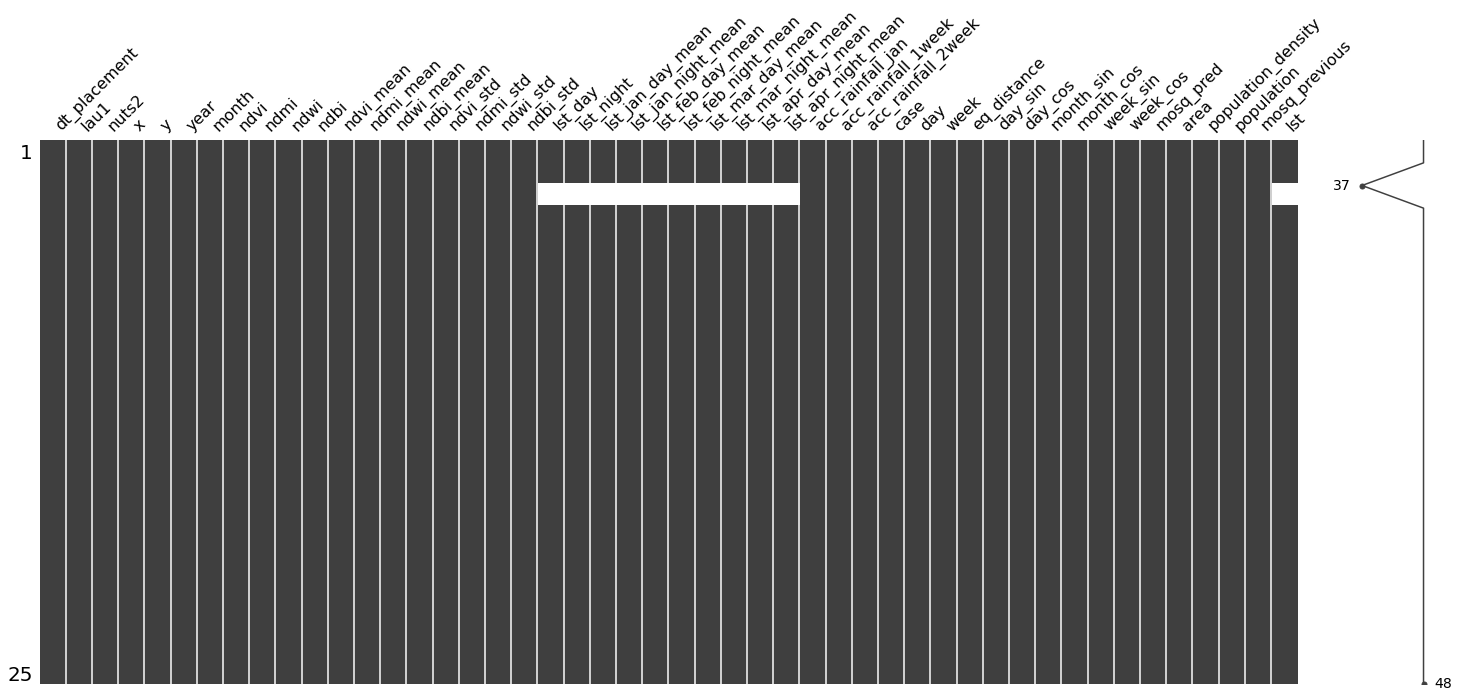

In [606]:
missingno.matrix(dataset)

In [607]:
dataset['case'].value_counts()

0    25
Name: case, dtype: int64

In [608]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [609]:
dataset['case'].value_counts()

0    25
Name: case, dtype: int64

In [610]:
cols = dataset.columns

In [611]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'mosq_pred', 'area',
       'population_density', 'population', 'mosq_previous', 'lst'],
      dtype='object')

In [612]:
len(cols)

48

In [613]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [614]:
len(rearranged_columns)

48

In [615]:
dataset = dataset[rearranged_columns].copy()

In [616]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.76105,39.69186,2023-08-01,θεσσαλιας,αγιας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,661.8,10705.00,17.3,45.75488,0.557438,0.178412,-0.487907,-0.178412,0.520525,0.179898,-0.454158,-0.179898,0.051547,0.045856,0.036236,0.045856,26.007188,30.631250,21.383125,10.418186,4.056923,10.285211,3.423839,16.670680,6.227661,17.857476,7.916795,0.000000,0.000000,184.584776,33,0,0
1,22.72671,39.12560,2023-08-01,θεσσαλιας,αλμυρου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,905.4,16004.00,20.6,45.24728,0.420595,0.107140,-0.386961,-0.107140,0.395690,0.099732,-0.366670,-0.099732,0.072532,0.065109,0.051319,0.065109,28.216667,34.460833,21.972500,11.219310,3.845804,10.731281,3.006374,16.701534,6.377584,19.115966,8.094541,0.000111,0.000111,278.949415,35,0,0
2,23.99842,39.24585,2023-08-01,θεσσαλιας,αλοννησου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,129.6,3153.00,21.2,46.00175,-0.253788,0.387324,0.474667,-0.387324,-0.232008,0.321657,0.441268,-0.321657,0.015256,0.046027,0.024071,0.046027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,255.685311,1,0,0
3,21.48510,39.29630,2023-08-01,θεσσαλιας,αργιθεας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,372.9,3515.00,9.3,44.78626,0.555144,0.196079,-0.487694,-0.196079,0.557115,0.191109,-0.488342,-0.191109,0.077085,0.064546,0.052469,0.064546,22.970769,26.848462,19.093077,6.942786,1.831897,7.062325,-0.605892,13.120876,3.695211,13.925591,4.285066,0.000000,0.000000,229.373225,41,0,0
4,22.93502,39.38117,2023-08-01,θεσσαλιας,βολου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,385.6,138865.00,374.6,45.57293,0.390260,0.033993,-0.363181,-0.033993,0.334020,0.026989,-0.317529,-0.026989,0.057719,0.059415,0.050660,0.059415,28.627500,34.916667,22.338333,12.159420,4.198851,11.394699,3.845437,17.241419,5.994943,19.899661,8.124530,0.000000,0.000000,208.427446,50,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,22.54288,39.85090,2023-08-01,θεσσαλιας,τεμπων,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,576.7,11.99,23.8,45.78510,0.413375,0.085477,-0.382376,-0.085477,0.389791,0.067347,-0.366998,-0.067347,0.054164,0.050260,0.041220,0.050260,27.657692,33.296154,22.019231,10.393561,3.008886,10.390640,2.134856,17.025728,5.961143,18.830436,7.729538,0.000000,0.000000,151.094659,84,0,0
21,21.77435,39.61293,2023-08-01,θεσσαλιας,τρικκαιων,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,607.6,78508.00,133.9,45.20295,0.438171,0.055794,-0.434343,-0.055794,0.450294,0.074011,-0.440591,-0.074011,0.067055,0.061030,0.042668,0.061030,29.110909,34.813636,23.408182,10.922628,2.735207,14.192480,2.120900,19.540155,6.658879,21.734176,8.015175,0.000000,0.000000,327.791186,90,0,0
22,22.29611,39.76297,2023-08-01,θεσσαλιας,τυρναβου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,525.3,22252.00,47.7,45.58739,0.297228,-0.051208,-0.340381,0.051208,0.315149,-0.031116,-0.346138,0.031116,0.060882,0.054054,0.039207,0.054054,30.976667,38.295833,23.657500,11.311522,2.577424,12.981529,1.941739,19.513585,6.457861,22.332175,8.544438,0.000000,0.000000,135.011355,111,0,0
23,22.02629,39.60300,2023-08-01,θεσσαλιας,φαρκαδονας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,368.7,11348.00,36.3,45.31617,0.372659,-0.019761,-0.403419,0.019761,0.365735,-0.028541

### Add geomorphological features ###

In [617]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [618]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 1.0396581258914785
Max distance: 11.290651157962253


In [619]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [620]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.76105,39.69186,2023-08-01,θεσσαλιας,αγιας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,661.8,10705.0,17.3,45.75488,0.557438,0.178412,-0.487907,-0.178412,0.520525,0.179898,-0.454158,-0.179898,0.051547,0.045856,0.036236,0.045856,26.007188,30.631250,21.383125,10.418186,4.056923,10.285211,3.423839,16.670680,6.227661,17.857476,7.916795,0.000000,0.000000,184.584776,33,0,0,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709
1,22.72671,39.12560,2023-08-01,θεσσαλιας,αλμυρου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,905.4,16004.0,20.6,45.24728,0.420595,0.107140,-0.386961,-0.107140,0.395690,0.099732,-0.366670,-0.099732,0.072532,0.065109,0.051319,0.065109,28.216667,34.460833,21.972500,11.219310,3.845804,10.731281,3.006374,16.701534,6.377584,19.115966,8.094541,0.000111,0.000111,278.949415,35,0,0,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750
2,23.99842,39.24585,2023-08-01,θεσσαλιας,αλοννησου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,129.6,3153.0,21.2,46.00175,-0.253788,0.387324,0.474667,-0.387324,-0.232008,0.321657,0.441268,-0.321657,0.015256,0.046027,0.024071,0.046027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,255.685311,1,0,0,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994
3,21.48510,39.29630,2023-08-01,θεσσαλιας,αργιθεας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,372.9,3515.0,9.3,44.78626,0.555144,0.196079,-0.487694,-0.196079,0.557115,0.191109,-0.488342,-0.191109,0.077085,0.064546,0.052469,0.064546,22.970769,26.848462,19.093077,6.942786,1.831897,7.062325,-0.605892,13.120876,3.695211,13.925591,4.285066,0.000000,0.000000,229.373225,41,0,0,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393
4,22.93502,39.38117,2023-08-01,θεσσαλιας,βολου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,385.6,138865.0,374.6,45.57293,0.390260,0.033993,-0.363181,-0.033993,0.334020,0.026989,-0.317529,-0.026989,0.057719,0.059415,0.050660,0.059415,28.627500,34.916667,22.338333,12.159420,4.198851,11.394699,3.845437,17.241419,5.994943,19.899661,8.124530,0.000000,0.000000,208.427446,50,0,0,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743


<AxesSubplot:>

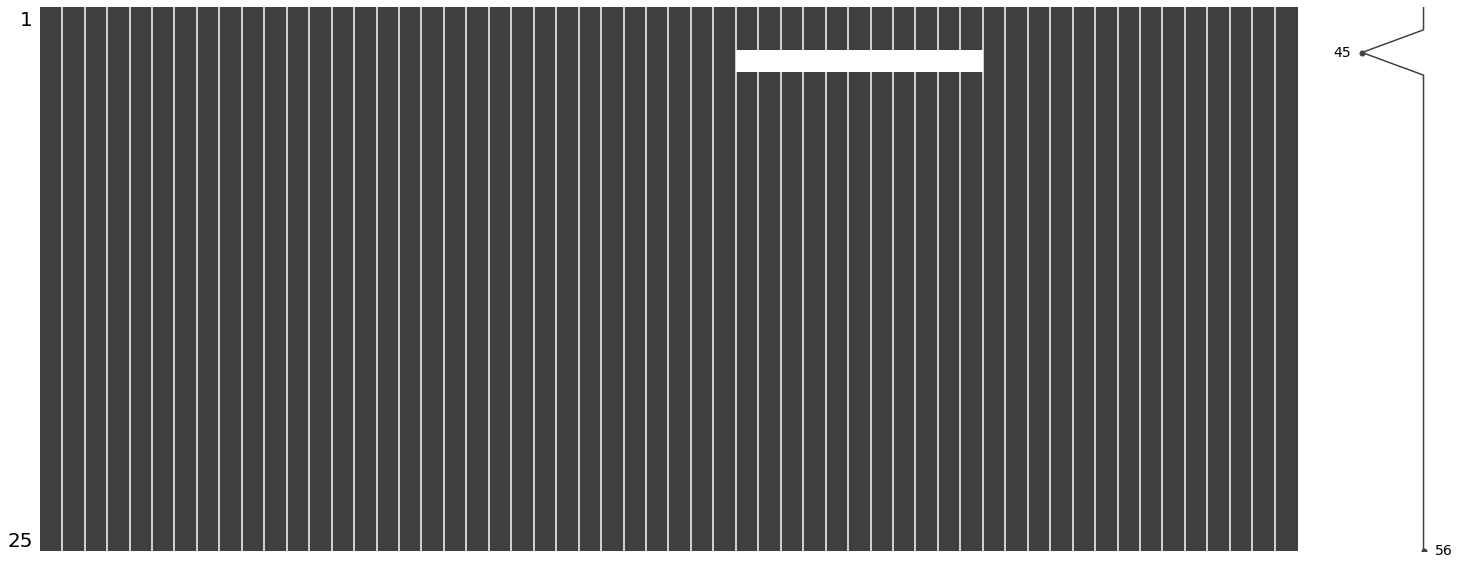

In [621]:
missingno.matrix(dataset)

In [622]:
cols = dataset.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [623]:
len(cols)

56

In [624]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [625]:
len(rearranged_columns)

56

In [626]:
dataset = dataset[rearranged_columns]

### Add Landcover features ###

In [627]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [628]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [629]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))
    

In [630]:
data_years = dataset['year'].unique().tolist()

In [631]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [632]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2023
Min distance: 1.0396581258914785
Max distance: 11.290651157962253


In [633]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

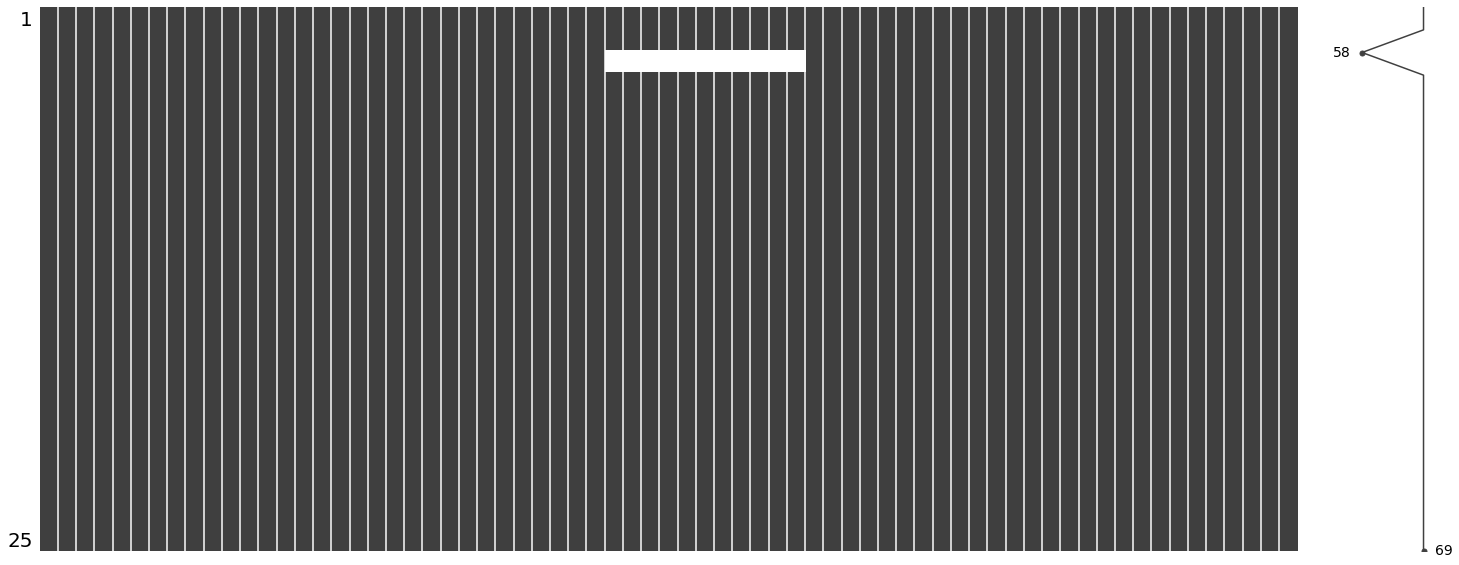

In [634]:
missingno.matrix(dataset_final)

In [635]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case',
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment',
       'lc_prop3', 'lc_prop3_assessment', '

In [636]:
len(cols)

69

In [637]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [638]:
len(rearranged)

69

In [639]:
dataset_final = dataset_final[rearranged]

In [640]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)